# S&P 500 — multivariate conventional-methods comparison

The repo's **financial-markets** reference: a head-to-head of conventional
time-series methods on a daily equity index, all reading the **same leak-safe
covariate panel** (VIX, Treasury yields, the 2s10s spread, fed funds, CPI,
unemployment, oil, gold, the dollar index, NASDAQ), plus an LLM-Process
forecaster that can read those covariates in its prompt.

> Given the same macro/market observations, **which method forecasts the index
> best — and can an LLM-Process, handed those covariates, keep up with gradient
> boosting?**

Unlike the energy/oil reference (univariate price trajectory forecast by
news-grounded / code-executing / adaptive **agents**), this is a clean,
reproducible **numerical-methods bake-off across a covariate panel** — no agents,
no news — scored with CRPS and direction metrics.

**Methods**

| Family | Predictors | Covariates? |
|---|---|---|
| Naive floor | `LastValuePredictor` | — |
| Classical | ETS, Kalman, AutoARIMA | — (univariate) |
| ML regression | Darts LinearRegression, LightGBM | ✅ optional past covariates |
| LLM-Process | `SampledTrajectoryLLMPredictor` | ✅ optional covariate prompt blocks |

**Workflow:** iterate on the **2025 backtest** (`Section 5`), then spend the
**protected 2026 eval** (`Section 7`) on your finalists. Pick the backtest spec
in the config cell; `specs/sp500_smoke.yaml` is the fast default.

## What's actually forecastable at daily resolution?

- **Target = returns, not the index level.** We forecast **close-to-close
  cumulative log returns** over a few horizons, one series per window:
  `sp500_logret_1b` (next session), `sp500_logret_5b` (forward 1 week),
  `sp500_logret_21b` (forward 1 month). Forecasting `sp500_logret_Nb` exactly `N`
  business days ahead resolves to the **forward** cumulative return over the next
  `N` sessions.
- **Per horizon:** `h=1` → direction / next-day **risk management**; `h=5`/`h=21`
  → tactical rebalancing and option tenors as cumulative returns.
- **The caveat:** for an index the return *level* is close to a martingale, so
  far-ahead point forecasts trend toward ~0; the forecastable, actionable objects
  are **volatility, tail risk, and direction**. That's why a VIX-led panel helps
  most at short horizons — watch the edge shrink as the horizon grows.

## ⚠️ Cutoff-aware evaluation — why the windows are what they are

This is the methodological heart of the comparison, and it's easy to get wrong.

- **Numerical methods are cutoff-safe by construction.** Naive, ETS, Kalman,
  AutoARIMA, LinReg and LightGBM only ever see the series up to the forecast
  origin (`ForecastContext` enforces it). They can be backtested on *any*
  historical window — including the 2020 COVID crash.
- **An LLM is not.** Gemini's training cutoff is ~**January 2025**, so it has
  effectively **memorised** outcomes before then. Scoring an LLM-Process on a
  pre-2025 origin measures *recall*, not forecasting — and silently flatters it
  in the head-to-head, which is exactly the comparison this notebook is about.

So the LLM-inclusive comparison lives **after the cutoff**:

| Window | Spec | Role | LLMP? |
|---|---|---|---|
| **2025** | `sp500_smoke.yaml` / `sp500_backtest_2025.yaml` | open iteration & comparison | ✅ post-cutoff |
| **2026** | `sp500_eval_2026.yaml` | **protected** held-out test (budgeted) | ✅ post-cutoff |
| **2020 COVID** | `sp500_stress_2020.yaml` | volatile-regime stress, **numerical only** | ❌ leaked for LLMs |

The 2020 stress spec keeps the LLMP rows off on purpose (its header explains
why). To study it, just point `BACKTEST_CONFIG_PATH` at it and re-run Section 5 —
the numerical methods are perfectly valid there.

---
## 1. Configuration

`BACKTEST_CONFIG_PATH` drives the 2025 comparison (Section 5); the eval spec
(Section 7) is fixed to the protected 2026 window. Each spec's `horizons` list
becomes one backtest/eval per `sp500_logret_{h}b` target.

In [1]:
from __future__ import annotations

import yaml


# 2025 comparison: sp500_smoke (fast, LLMP on) | sp500_backtest_2025 | sp500_stress_2020 (numerical-only)
BACKTEST_CONFIG_PATH = "./specs/sp500_smoke.yaml"
# Protected held-out test (2026):
EVAL_CONFIG_PATH = "./specs/sp500_eval_2026.yaml"


def _load(path: str) -> dict:
    with open(path, encoding="utf-8") as f:
        return yaml.safe_load(f)


BT, EV = _load(BACKTEST_CONFIG_PATH), _load(EVAL_CONFIG_PATH)
_btw, _bx = BT["backtest"], BT["experiment"]
_evw, _ex = EV["eval"], EV["experiment"]

# --- 2025 backtest window ---
BT_HORIZONS = [int(h) for h in _btw["horizons"]]
BT_START, BT_END, BT_STRIDE, BT_WARMUP = _btw["start"], _btw["end"], int(_btw["stride"]), int(_btw["warmup"])
BT_DESC = _btw.get("description", "")
BT_RUN_MODELS = dict(_bx["run_models"])
BT_COVS = list(_bx["covariate_series_ids"])
DATA_HISTORY_START = _bx["data_history_start"]
REFRESH_CACHE = bool(_bx["refresh_cache"])
LAGS, LAGS_PC, NUM_SAMPLES = int(_bx["lags"]), int(_bx["lags_past_covariates"]), int(_bx["num_samples"])
LLMP_N, LLMP_HW, LLMP_RE = (
    int(_bx.get("llmp_n_samples", 10)),
    int(_bx.get("llmp_history_window", 64)),
    _bx.get("llmp_reasoning_effort"),
)
LGBM = dict(_bx["lightgbm_kwargs"])

# --- 2026 protected eval window ---
EV_HORIZONS = [int(h) for h in _evw["horizons"]]
EV_START, EV_END, EV_STRIDE, EV_WARMUP = _evw["start"], _evw["end"], int(_evw["stride"]), int(_evw["warmup"])
EV_DESC, EV_SPEC_ID, EV_MAX_RUNS = _evw.get("description", ""), _evw["spec_id"], _evw.get("max_runs")
EV_RUN_MODELS = dict(_ex["run_models"])
EV_COVS = list(_ex["covariate_series_ids"])
EV_NUM_SAMPLES = int(_ex["num_samples"])
EV_LLMP_N, EV_LLMP_HW, EV_LLMP_RE = (
    int(_ex.get("llmp_n_samples", 10)),
    int(_ex.get("llmp_history_window", 64)),
    _ex.get("llmp_reasoning_effort"),
)
EV_LGBM = dict(_ex["lightgbm_kwargs"])

print(f"Backtest : {BACKTEST_CONFIG_PATH}  ·  {BT_START} → {BT_END} (stride {BT_STRIDE})  ·  horizons {BT_HORIZONS}")
print(f"           models on: {[k for k, v in BT_RUN_MODELS.items() if v]}")
print(f"Eval     : {EVAL_CONFIG_PATH}  ·  {EV_START} → {EV_END}  ·  spec_id {EV_SPEC_ID}  ·  max_runs {EV_MAX_RUNS}")
print(f"           finalists: {[k for k, v in EV_RUN_MODELS.items() if v]}")

Backtest : ./specs/sp500_smoke.yaml  ·  2025-10-06 → 2025-11-14 (stride 5)  ·  horizons [1, 5, 21]
           models on: ['naive_last_value', 'ets_target_only', 'kalman_target_only', 'linreg_target_only', 'linreg_with_covariates', 'lightgbm_target_only', 'lightgbm_with_covariates', 'llmp_target_only', 'llmp_with_covariates']
Eval     : ./specs/sp500_eval_2026.yaml  ·  2026-02-02 → 2026-03-23  ·  spec_id sp500_eval_2026  ·  max_runs 5
           finalists: ['naive_last_value', 'lightgbm_with_covariates', 'llmp_target_only', 'llmp_with_covariates']


---
## 2. Imports & environment

In [2]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv


warnings.filterwarnings("ignore")
load_dotenv("../../.env")  # LLMP rows call the Vector proxy — need PROXY_* set

from aieng.forecasting.evaluation import BacktestSpec, EvalSpec, describe_spec
from aieng.forecasting.evaluation.task import ForecastingTask
from sp500_forecasting import build_sp500_multivariate_service
from sp500_forecasting.backtest_grid import (
    build_return_compare_frame,
    run_backtest_for_run_key,
    run_horizon_eval,
    run_horizon_grid,
)
from sp500_forecasting.data import sp500_logret_series_id
from sp500_forecasting.plots import (
    display_multivariate_backtest_leaderboard,
    plot_return_forecast_vs_actual_multi,
    plot_sp500_log_return_recent,
)

---
## 3. Build data services

`svc_no_cov` (targets only) and `svc_cov` (targets + the full covariate panel),
registering one cumulative-return target per horizon used by either spec.

**First run on 2025/2026 windows?** Warm the caches to the present first:
`uv run python scripts/fetch_sp500_market.py --refresh` (Yahoo: ^GSPC/^VIX/^IXIC)
and `uv run python scripts/fetch_fred.py` (macro covariates).

In [3]:
ALL_COVS = sorted(set(BT_COVS) | set(EV_COVS))
ALL_HORIZONS = sorted(set(BT_HORIZONS) | set(EV_HORIZONS))

svc_no_cov = build_sp500_multivariate_service(
    windows=tuple(ALL_HORIZONS),
    include_covariates=False,
    start=DATA_HISTORY_START,
    refresh=REFRESH_CACHE,
)
svc_cov = build_sp500_multivariate_service(
    windows=tuple(ALL_HORIZONS),
    include_covariates=True,
    covariate_series_ids=ALL_COVS,
    start=DATA_HISTORY_START,
    refresh=REFRESH_CACHE,
)

registered = set(svc_cov.series_ids)
bt_covariates = [c for c in BT_COVS if c in registered]
ev_covariates = [c for c in EV_COVS if c in registered]
print("targets:", list(svc_no_cov.series_ids))
print(f"covariates registered: {len(registered & set(ALL_COVS))} / {len(ALL_COVS)} requested")
print("backtest covariates:", bt_covariates)

targets: ['sp500_logret_1b', 'sp500_logret_21b', 'sp500_logret_5b']
covariates registered: 10 / 11 requested
backtest covariates: ['vix_level_l1b', 'vix_log_ret_1b_l1b', 'ust10y_level_l1b', 'ust2y10y_spread_l1b', 'nasdaq_log_ret_1b_l1b', 'oil_log_ret_1b_l1b']


---
## 4. Target context — observed returns

The most recent realised next-session returns (the `h=1` target). Blue = index up
over the window, red = down.

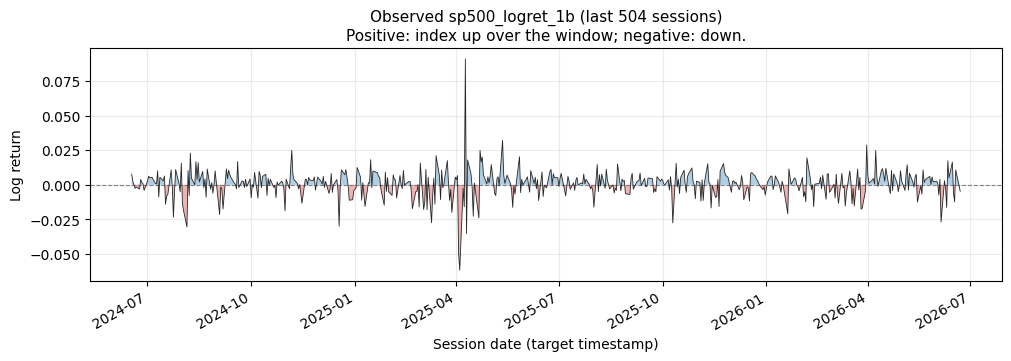

In [4]:
fig, _ = plot_sp500_log_return_recent(svc_no_cov, n_trading_days=504)
plt.show()

---
## 5. 2025 backtest — the comparison (post-cutoff)

One single-horizon `BacktestSpec` per horizon. `run_horizon_grid` runs every
enabled model once per horizon and prints **live progress** (which model is
running, then its CRPS / error and elapsed time).

In [5]:
bt_specs = {
    h: BacktestSpec(
        task=ForecastingTask(
            task_id=f"sp500_logret_{h}b",
            target_series_id=sp500_logret_series_id(h),
            horizons=[h],
            frequency="B",
            description=f"S&P 500 close-to-close cumulative log return, {h} business day(s) ahead.",
        ),
        start=BT_START,
        end=BT_END,
        stride=BT_STRIDE,
        warmup=BT_WARMUP,
        description=BT_DESC,
    )
    for h in BT_HORIZONS
}
print(describe_spec(bt_specs[BT_HORIZONS[0]], data_service=svc_cov))

BacktestSpec
  description: Smoke multivariate demo: weekly origins in late 2025 (post-cutoff), forecasting close-to-close cumulative returns at 1/5/21 business days.
  start:       2025-10-06 00:00:00
  end:         2025-11-14 00:00:00
  stride:      5
  warmup:      250

Task: sp500_logret_1b
  description: S&P 500 close-to-close cumulative log return, 1 business day(s) ahead.
  horizons:    1
  frequency:   B
  payload:     continuous
  resolution:  observed_value_at_resolution_timestamp
- target_series_id: sp500_logret_1b
    description:    S&P 500 close-to-close cumulative log return over 1 business day(s) (next-session) (Yahoo Finance ^GSPC, derived)
    source:         Yahoo Finance (^GSPC), derived
    units:          log-return
    frequency:      B


In [6]:
RESULTS_DF = run_horizon_grid(
    run_models=BT_RUN_MODELS,
    specs_by_horizon=bt_specs,
    selected_covariates=bt_covariates,
    svc_no_cov=svc_no_cov,
    svc_cov=svc_cov,
    lags=LAGS,
    lags_past_covariates=LAGS_PC,
    num_samples=NUM_SAMPLES,
    lightgbm_kwargs=LGBM,
    llmp_n_samples=LLMP_N,
    llmp_history_window=LLMP_HW,
    llmp_reasoning_effort=LLMP_RE,
)

Horizon 1/3 · h=1 → sp500_logret_1b · 9 model(s)
    [h= 1] (1/9) naive_last_value … ✓ CRPS=0.01196  (0.2s)
    [h= 1] (2/9) ets_target_only … ✓ CRPS=0.00394  (0.2s)
    [h= 1] (3/9) kalman_target_only … ✓ CRPS=0.00389  (1.0s)
    [h= 1] (4/9) linreg_target_only … ✓ CRPS=0.00367  (5.5s)
    [h= 1] (5/9) linreg_with_covariates … ✓ CRPS=0.00308  (10.6s)
    [h= 1] (6/9) lightgbm_target_only … ✓ CRPS=0.00424  (2.5s)
    [h= 1] (7/9) lightgbm_with_covariates … ✓ CRPS=0.00347  (10.8s)
    [h= 1] (8/9) llmp_target_only … ✓ CRPS=0.00360  (8.2s)
    [h= 1] (9/9) llmp_with_covariates … ✓ CRPS=0.00369  (6.9s)
Horizon 2/3 · h=5 → sp500_logret_5b · 9 model(s)
    [h= 5] (1/9) naive_last_value … ✓ CRPS=0.01721  (0.0s)
    [h= 5] (2/9) ets_target_only … ✓ CRPS=0.01305  (0.1s)
    [h= 5] (3/9) kalman_target_only … ✓ CRPS=0.00880  (1.0s)
    [h= 5] (4/9) linreg_target_only … ✓ CRPS=0.01038  (24.5s)
    [h= 5] (5/9) linreg_with_covariates … ✓ CRPS=0.00823  (39.3s)
    [h= 5] (6/9) lightgbm_target_only 

### Leaderboard — mean CRPS by method and horizon

Read it as a story: the spread between methods (and the naive floor's
disadvantage) is widest at `h=1` and compresses by `h=21`. The `dir_*` columns
report next-direction skill (most meaningful at `h=1`).

,horizon,target,run_key,model,uses_covariates,n_covariates,covariates,predictor_id,mean_crps,n_scores,n_predictions,skipped_origins,dir_precision_up,dir_recall_up,dir_f1_up,dir_accuracy,dir_roc_auc_prob_up,dir_n_eval,error
0,1,sp500_logret_1b,linreg_with_covariates,linreg with covariates,True,6,"vix_level_l1b, vix_log_ret_1b_l1b, ust10y_level_l1b, ust2y10y_spread_l1b, nasdaq_log_ret_1b_l1b, oil_log_ret_1b_l1b",darts_linreg_cov,0.00308,6,6,0,0.500,0.667,0.571,0.500,0.778,6,
1,1,sp500_logret_1b,lightgbm_with_covariates,lightgbm with covariates,True,6,"vix_level_l1b, vix_log_ret_1b_l1b, ust10y_level_l1b, ust2y10y_spread_l1b, nasdaq_log_ret_1b_l1b, oil_log_ret_1b_l1b",darts_lightgbm_cov,0.00347,6,6,0,0.600,1.000,0.750,0.667,0.667,6,
2,1,sp500_logret_1b,llmp_target_only,llmp target only,False,0,—,llmp_sampled_trajectories_target[gemini-3.1-flash-lite-preview],0.00360,6,6,0,0.000,0.000,0.000,0.500,0.500,6,
3,1,sp500_logret_1b,linreg_target_only,linreg target only,False,0,—,darts_linreg,0.00367,6,6,0,0.600,1.000,0.750,0.667,0.667,6,
4,1,sp500_logret_1b,llmp_with_covariates,llmp with covariates,True,6,"vix_level_l1b, vix_log_ret_1b_l1b, ust10y_level_l1b, ust2y10y_spread_l1b, nasdaq_log_ret_1b_l1b, oil_log_ret_1b_l1b",llmp_sampled_trajectories_cov[gemini-3.1-flash-lite-preview],0.00369,6,6,0,0.000,0.000,0.000,0.500,0.333,6,
5,1,sp500_logret_1b,kalman_target_only,kalman target only,False,0,—,darts_kalman,0.00389,6,6,0,1.000,0.667,0.800,0.833,0.778,6,
6,1,sp500_logret_1b,ets_target_only,ets target only,False,0,—,darts_ets,0.00394,6,6,0,0.333,0.333,0.333,0.333,0.444,6,
7,1,sp500_logret_1b,lightgbm_target_only,lightgbm target only,False,0,—,darts_lightgbm,0.00424,6,6,0,0.333,0.333,0.333,0.333,0.556,6,
8,1,sp500_logret_1b,naive_last_value,naive last value,False,0,—,last_value_naive,0.01196,6,6,0,0.500,1.000,0.667,0.500,0.500,6,
9,5,sp500_logret_5b,linreg_with_covariates,linreg with covariates,True,6,"vix_level_l1b, vix_log_ret_1b_l1b, ust10y_level_l1b, ust2y10y_spread_l1b, nasdaq_log_ret_1b_l1b, oil_log_ret_1b_l1b",darts_linreg_cov,0.00823,6,6,0,0.400,1.000,0.571,0.500,0.750,6,


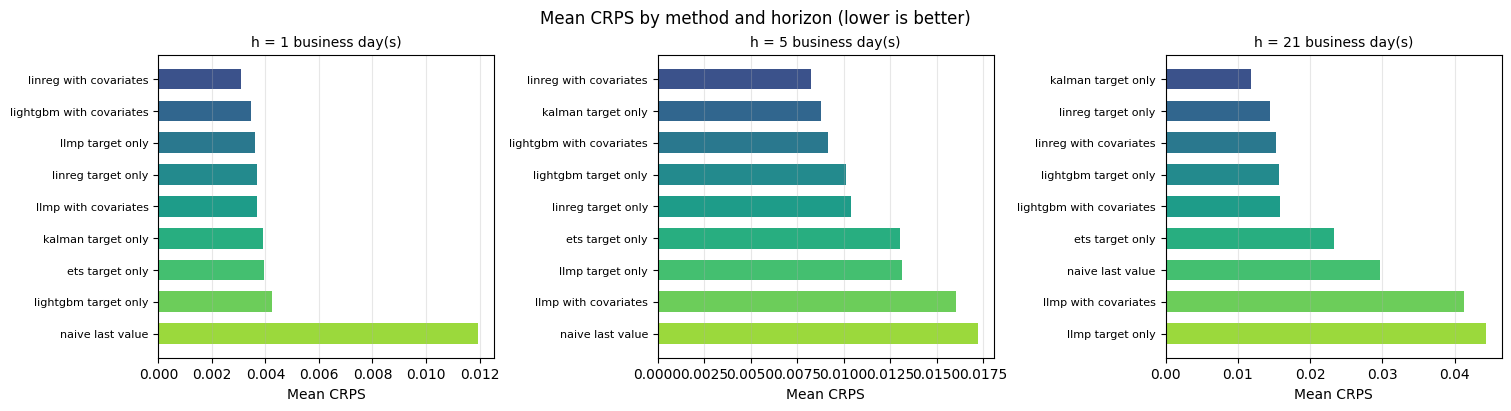

In [7]:
display_multivariate_backtest_leaderboard(RESULTS_DF)

### Reading the LLMP ± covariates rows

When enabled, compare directly:
- `llmp_sampled_trajectories_target[…]` — the LLM sees **only** the target history.
- `llmp_sampled_trajectories_cov[…]` — it additionally sees **labeled
  covariate-history blocks** (VIX, yields, …) in its prompt.

Their CRPS gap answers the headline question: does the same exogenous panel the
ML methods use help an LLM — and does either LLMP variant reach the
gradient-boosting rows? Because this is **2025 (post-cutoff)**, the LLM can't be
reciting memorised outcomes.

---
## 6. Forecast vs realised (next session, h=1)

A few fast models' median next-session forecast against the realised return
(percent) — the near-zero, low-amplitude forecasts vs the noisy realised series
are the daily-efficiency story made visual.

  (1/3) naive_last_value …
  (2/3) ets_target_only …
  (3/3) lightgbm_with_covariates …


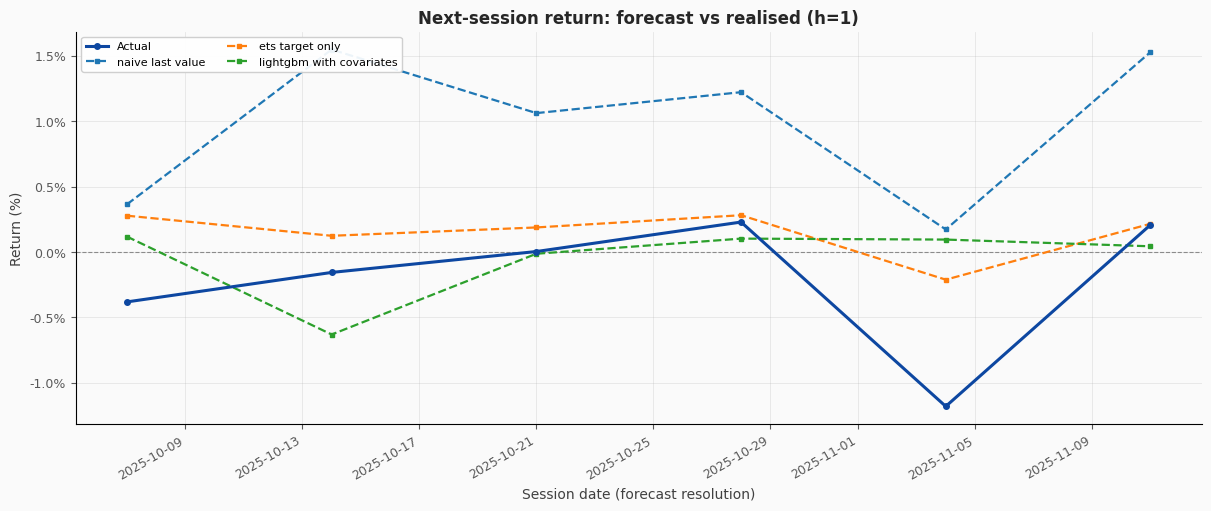

In [8]:
h1 = 1 if 1 in bt_specs else min(bt_specs)
h1_spec = bt_specs[h1]
demo_keys = [k for k in ("naive_last_value", "ets_target_only", "lightgbm_with_covariates") if BT_RUN_MODELS.get(k)]
compare_by_run: dict[str, pd.DataFrame] = {}
for di, key in enumerate(demo_keys, start=1):
    print(f"  ({di}/{len(demo_keys)}) {key} …", flush=True)
    res = run_backtest_for_run_key(
        run_key=key,
        spec=h1_spec,
        selected_covariates=bt_covariates,
        svc_no_cov=svc_no_cov,
        svc_cov=svc_cov,
        lags=LAGS,
        lags_past_covariates=LAGS_PC,
        num_samples=NUM_SAMPLES,
        lightgbm_kwargs=LGBM,
        llmp_n_samples=LLMP_N,
        llmp_history_window=LLMP_HW,
        llmp_reasoning_effort=LLMP_RE,
    )
    compare_by_run[key] = build_return_compare_frame(res.predictions, svc_cov, h1_spec.task.target_series_id)

fig, _ = plot_return_forecast_vs_actual_multi(
    compare_by_run, title=f"Next-session return: forecast vs realised (h={h1})"
)
plt.show()

---
## 7. Protected 2026 eval — the honest scoreboard

`evaluate()` against the held-out 2026 window. This is **scarce**: `sp500_eval_2026.yaml`
enables only a curated **finalist** set and carries `max_runs`. Pass an
`EvalTracker` to enforce that budget across sessions (commented below — it would
block re-runs once exhausted, so we leave it off here and just show `run_number`).

Spend it on the models you committed to from the 2025 backtest — not the whole
grid.

In [9]:
# from pathlib import Path
# from aieng.forecasting.evaluation import EvalTracker
# tracker = EvalTracker(Path("../../data/sp500_eval_runs.json"))  # enforces max_runs across sessions

eval_specs = {
    h: EvalSpec(
        spec_id=f"{EV_SPEC_ID}_h{h}",
        max_runs=EV_MAX_RUNS,
        task=ForecastingTask(
            task_id=f"sp500_logret_{h}b",
            target_series_id=sp500_logret_series_id(h),
            horizons=[h],
            frequency="B",
            description=f"S&P 500 close-to-close cumulative log return, {h} business day(s) ahead.",
        ),
        start=EV_START,
        end=EV_END,
        stride=EV_STRIDE,
        warmup=EV_WARMUP,
        description=EV_DESC,
    )
    for h in EV_HORIZONS
}

EVAL_DF = run_horizon_eval(
    run_models=EV_RUN_MODELS,
    eval_specs_by_horizon=eval_specs,
    selected_covariates=ev_covariates,
    svc_no_cov=svc_no_cov,
    svc_cov=svc_cov,
    lags=LAGS,
    lags_past_covariates=LAGS_PC,
    num_samples=EV_NUM_SAMPLES,
    lightgbm_kwargs=EV_LGBM,
    llmp_n_samples=EV_LLMP_N,
    llmp_history_window=EV_LLMP_HW,
    llmp_reasoning_effort=EV_LLMP_RE,
    tracker=None,  # set to `tracker` above to enforce the max_runs budget
)

Eval horizon 1/3 · h=1 → sp500_logret_1b · 4 model(s)  [spec_id=sp500_eval_2026_h1]
    [h= 1] (1/4) naive_last_value … ✓ CRPS=0.01043  (run #1, 0.0s)
    [h= 1] (2/4) lightgbm_with_covariates … ✓ CRPS=0.00431  (run #1, 19.2s)
    [h= 1] (3/4) llmp_target_only … ✓ CRPS=0.00478  (run #1, 10.5s)
    [h= 1] (4/4) llmp_with_covariates … ✓ CRPS=0.00501  (run #1, 14.7s)
Eval horizon 2/3 · h=5 → sp500_logret_5b · 4 model(s)  [spec_id=sp500_eval_2026_h5]
    [h= 5] (1/4) naive_last_value … ✓ CRPS=0.00984  (run #1, 0.0s)
    [h= 5] (2/4) lightgbm_with_covariates … ✓ CRPS=0.01176  (run #1, 72.2s)
    [h= 5] (3/4) llmp_target_only … ✓ CRPS=0.01303  (run #1, 9.8s)
    [h= 5] (4/4) llmp_with_covariates … ✓ CRPS=0.01388  (run #1, 12.6s)
Eval horizon 3/3 · h=21 → sp500_logret_21b · 4 model(s)  [spec_id=sp500_eval_2026_h21]
    [h=21] (1/4) naive_last_value … ✓ CRPS=0.04483  (run #1, 0.0s)
    [h=21] (2/4) lightgbm_with_covariates … ✓ CRPS=0.03806  (run #1, 280.1s)
    [h=21] (3/4) llmp_target_only … 

,horizon,target,run_key,model,uses_covariates,n_covariates,covariates,predictor_id,mean_crps,n_scores,n_predictions,skipped_origins,dir_precision_up,dir_recall_up,dir_f1_up,dir_accuracy,dir_roc_auc_prob_up,dir_n_eval,error,run_number
0,1,sp500_logret_1b,lightgbm_with_covariates,lightgbm with covariates,True,10,"vix_level_l1b, vix_log_ret_1b_l1b, ust10y_level_l1b, ust2y10y_spread_l1b, fed_funds_level_l1b, cpi_mom_logdiff_l1b, unemployment_rate_l1b, oil_log_ret_1b_l1b, dollar_index_log_ret_1b_l1b, nasdaq_log_ret_1b_l1b",darts_lightgbm_cov,0.00431,8,8,0,0.333,0.333,0.333,0.500,0.467,8,,1
1,1,sp500_logret_1b,llmp_target_only,llmp target only,False,0,—,llmp_sampled_trajectories_target[gemini-3.1-flash-lite-preview],0.00478,8,8,0,0.000,0.000,0.000,0.625,0.500,8,,1
2,1,sp500_logret_1b,llmp_with_covariates,llmp with covariates,True,10,"vix_level_l1b, vix_log_ret_1b_l1b, ust10y_level_l1b, ust2y10y_spread_l1b, fed_funds_level_l1b, cpi_mom_logdiff_l1b, unemployment_rate_l1b, oil_log_ret_1b_l1b, dollar_index_log_ret_1b_l1b, nasdaq_log_ret_1b_l1b",llmp_sampled_trajectories_cov[gemini-3.1-flash-lite-preview],0.00501,8,8,0,0.000,0.000,0.000,0.625,0.500,8,,1
3,1,sp500_logret_1b,naive_last_value,naive last value,False,0,—,last_value_naive,0.01043,8,8,0,0.286,0.667,0.400,0.250,0.333,8,,1
4,5,sp500_logret_5b,naive_last_value,naive last value,False,0,—,last_value_naive,0.00984,7,7,1,0.333,0.500,0.400,0.571,0.550,7,,1
5,5,sp500_logret_5b,lightgbm_with_covariates,lightgbm with covariates,True,10,"vix_level_l1b, vix_log_ret_1b_l1b, ust10y_level_l1b, ust2y10y_spread_l1b, fed_funds_level_l1b, cpi_mom_logdiff_l1b, unemployment_rate_l1b, oil_log_ret_1b_l1b, dollar_index_log_ret_1b_l1b, nasdaq_log_ret_1b_l1b",darts_lightgbm_cov,0.01176,7,7,1,0.333,1.000,0.500,0.429,0.700,7,,1
6,5,sp500_logret_5b,llmp_target_only,llmp target only,False,0,—,llmp_sampled_trajectories_target[gemini-3.1-flash-lite-preview],0.01303,7,7,1,0.400,1.000,0.571,0.571,0.950,7,,1
7,5,sp500_logret_5b,llmp_with_covariates,llmp with covariates,True,10,"vix_level_l1b, vix_log_ret_1b_l1b, ust10y_level_l1b, ust2y10y_spread_l1b, fed_funds_level_l1b, cpi_mom_logdiff_l1b, unemployment_rate_l1b, oil_log_ret_1b_l1b, dollar_index_log_ret_1b_l1b, nasdaq_log_ret_1b_l1b",llmp_sampled_trajectories_cov[gemini-3.1-flash-lite-preview],0.01388,7,7,1,0.250,0.500,0.333,0.429,0.600,7,,1
8,21,sp500_logret_21b,lightgbm_with_covariates,lightgbm with covariates,True,10,"vix_level_l1b, vix_log_ret_1b_l1b, ust10y_level_l1b, ust2y10y_spread_l1b, fed_funds_level_l1b, cpi_mom_logdiff_l1b, unemployment_rate_l1b, oil_log_ret_1b_l1b, dollar_index_log_ret_1b_l1b, nasdaq_log_ret_1b_l1b",darts_lightgbm_cov,0.03806,8,8,0,0.250,1.000,0.400,0.250,0.250,8,,1
9,21,sp500_logret_21b,llmp_with_covariates,llmp with covariates,True,10,"vix_level_l1b, vix_log_ret_1b_l1b, ust10y_level_l1b, ust2y10y_spread_l1b, fed_funds_level_l1b, cpi_mom_logdiff_l1b, unemployment_rate_l1b, oil_log_ret_1b_l1b, dollar_index_log_ret_1b_l1b, nasdaq_log_ret_1b_l1b",llmp_sampled_trajectories_cov[gemini-3.1-flash-lite-preview],0.03969,8,8,0,0.286,1.000,0.444,0.375,0.667,8,,1


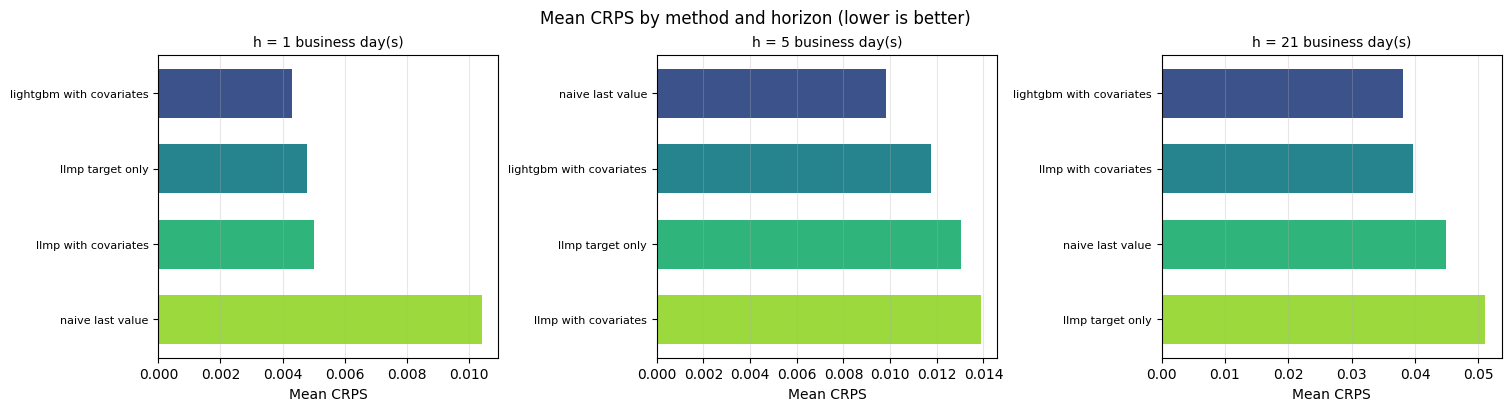

In [10]:
display_multivariate_backtest_leaderboard(EVAL_DF)

---
## Where to go next

- **Scale up the backtest.** Re-run Section 5 with `specs/sp500_backtest_2025.yaml`
  (weekly origins across all of 2025, full panel, AutoARIMA on). Enable the
  `llmp_*` rows deliberately — they're slow over ~50 origins.
- **Study the COVID regime (numerical only).** Point `BACKTEST_CONFIG_PATH` at
  `specs/sp500_stress_2020.yaml` and re-run Section 5: a volatile window where a
  covariate edge is most visible. Its LLMP rows are off on purpose — 2020 is
  pre-cutoff, so an LLM would be reciting, not forecasting.
- **Add a Darts method.** Mirror `aieng/forecasting/methods/numerical/darts_classical.py`,
  export it, add a `run_key` branch in `backtest_grid.py`, toggle it in a spec.
- **Experiment with different base models for LLMPs** How do the results look
  when different models are selected?
- **Try an agentic forecaster** with the same backtest caveats as LLMP. Do agents provide
  any lift over LLMPs or conventional methods?  
- **Spend the eval honestly.** Wire the `EvalTracker` in Section 7 so `max_runs`
  is enforced, and only evaluate models you've committed to.